In [5]:
import numpy as np
import importlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import time

# Import Pandora Library Functions with autoreload
import pandora_funcs

pandora = importlib.reload(pandora_funcs)

try:
	from IPython import get_ipython
	ip = get_ipython()
	if ip is not None:
		ip.run_line_magic('load_ext', 'autoreload')
		ip.run_line_magic('autoreload', '2')
except Exception:
	pass

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# location data products
datadir = '/opt/data2/rowe/pandora/2026/RDF1/data/'
science_file = 'Pandora_RDF_WASP-178b_all.fits'
fits_path = datadir + science_file

# Tunable bad-pixel/clump-repair settings.
badpix_params = {
	"min_intercept_offset_dn": 250.0,
	"intercept_sigma": 10.0,
	"slope_percentile": 0.5,
	"scatter_sigma": 10.0,
	"core_dilate_iterations": 0,
	# Tune this to control how far we repair residual bright wings around bad cores.
	"wing_iterations": 1,
	"repair_max_radius": 3,
	"repair_min_neighbors": 4,
}

###  RAW SCIENCE is stored as (integration, group, row, column).

- ramp_cube : 443, 6, 400, 80
- cube: 2658, 400, 80
- nint = 443, ngroup = 6
- row_map[400, 80] = [907] x 80 ... [1306] x 80
- col_map[400, 80] = [1737 ... 1816] x 400
- exposure_time_s[2658] 0.9225, ...   

In [3]:

ramp_cube, science_header = pandora.read_rdf_raw_science(fits_path)
cube = pandora.flatten_ramp_cube(ramp_cube)
nint, ngroup = ramp_cube.shape[0], ramp_cube.shape[1]

row_map, col_map, exposure_time_s = pandora.get_rdf_auxiliary_data(fits_path)

print(f"Loaded RAW SCIENCE ramp with shape: {ramp_cube.shape} (nint={nint}, ngroup={ngroup})")
print(f"Flattened science cube shape: {cube.shape}")
print(f"SCIENCE EXTNAME: {science_header.get('EXTNAME', 'N/A')}")

if exposure_time_s is not None:
	print(
		f"Loaded EXPOSURE_TIME array: {exposure_time_s.shape}, "
		f"min={np.nanmin(exposure_time_s):.6g}s, max={np.nanmax(exposure_time_s):.6g}s"
	)

time_jd_cube = pandora.read_rdf_time_extension(fits_path)
print(
	f"Loaded TIME extension: {time_jd_cube.shape}, "
	f"jd range=({np.nanmin(time_jd_cube):.6f}, {np.nanmax(time_jd_cube):.6f})"
)

Loaded RAW SCIENCE ramp with shape: (443, 6, 400, 80) (nint=443, ngroup=6)
Flattened science cube shape: (2658, 400, 80)
SCIENCE EXTNAME: RAW SCIENCE
Loaded EXPOSURE_TIME array: (2658,), min=0.9225s, max=37.8225s
Loaded TIME extension: (443, 6), jd range=(2461154.705297, 2461155.138169)


### Display a frame from the datacube

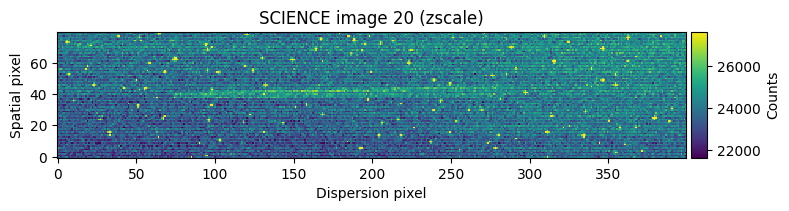

In [4]:
pandora.display_science_image(cube, image_index=20, scale_style="zscale")

In [7]:
# Typical NIRCam/NIRISS values (Adjust read_noise and gain based on your specific detector)
READ_NOISE = 12.0 # e-
GAIN = 1.5 # e-/DN

print("Compiling and processing...")
start_time = time.time()

times = exposure_time_s[0:ngroup]
slope_cube = pandora.get_slope_cube_owls(ramp_cube, times, read_noise=READ_NOISE, gain=GAIN, threshold=4.0)

print(f"Done! Processed {slope_cube.size} pixels in {time.time() - start_time:.3f} seconds.")

Compiling and processing...
Done! Processed 14176000 pixels in 5.441 seconds.


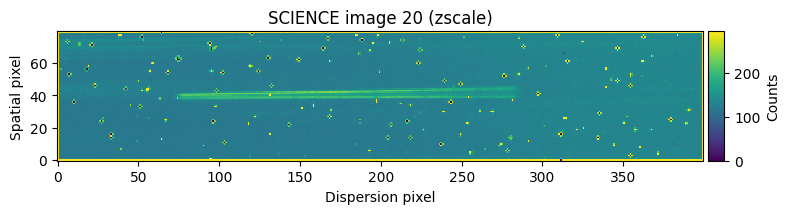

In [8]:
pandora.display_science_image(slope_cube, image_index=20, scale_style="zscale",iraf_contrast=0.99)